# Notebook for differential phase contrast (DPC)
This is a notebook to provide a boilerplate for a differential phase contrast (DPC) imaging routine triggered by the imswitch client.


Standalone DPC Processing Script using ImSwitchClient

This script performs DPC (Differential Phase Contrast) imaging by:
- Setting LED illumination patterns via ImSwitchClient
- Capturing images via HTTP requests
- Processing the images using the DPC reconstruction algorithm
- Displaying and optionally saving the results

Based on the ImSwitch DPCController implementation.

In [1]:

import numpy as np
import matplotlib.pyplot as plt
import time
import os
from datetime import datetime
from pathlib import Path
import tifffile as tif
from scipy.ndimage import uniform_filter
from dataclasses import dataclass, asdict
from typing import Optional, Tuple, Dict, Any

import imswitchclient.ImSwitchClient as imc

# NumPy helpers
pi = np.pi
naxis = np.newaxis
F = lambda x: np.fft.fft2(x)
IF = lambda x: np.fft.ifft2(x)




In [24]:


# =========================
# Configuration Dataclass
# =========================
@dataclass
class DPCConfig:
    """DPC processing configuration"""
    # Optical parameters
    pixelsize: float = 0.2  # micrometers
    wavelength: float = 0.53  # micrometers (green light)
    na: float = 0.3  # Numerical aperture
    nai: float = 0.0  # Inner NA
    n: float = 1.0  # Refractive index
    stack_order : list = (0,1,2,3)  # Order of LED patterns: right, left, top, bottom
    # LED parameters
    led_intensity_r: int = 0  # Red channel intensity
    led_intensity_g: int = 255  # Green channel intensity (default)
    led_intensity_b: int = 0  # Blue channel intensity
    wait_time: float = 0.2  # seconds between LED changes
    
    # Regularization parameters
    reg_u: float = 1e-1  # Tikhonov regularization for absorption
    reg_p: float = 5e-3  # Tikhonov regularization for phase
    
    # Saving options
    save_images: bool = True
    save_directory: str = "./dpc_results"
    
    def to_dict(self) -> Dict[str, Any]:
        return asdict(self)


# =========================
# DPC Solver (Waller Lab Algorithm)
# =========================
class DPCSolver:
    """
    DPC reconstruction algorithm
    Based on Waller Lab implementation:
    https://github.com/Waller-Lab/DPC/blob/master/python_code/dpc_algorithm.py
    """
    
    def __init__(self, shape, wavelength, na, NAi, pixelsize, rotation):
        self.shape = shape
        if self.shape[0] == 0:
            self.shape = (512, 512)
        
        self.wavelength = wavelength
        self.na = na
        self.NAi = NAi
        self.pixel_size = pixelsize
        self.dpc_num = len(rotation)
        self.rotation = rotation
        
        # Generate frequency grids
        self.fxlin = np.fft.ifftshift(self.genGrid(self.shape[-1], 1.0/self.shape[-1]/self.pixel_size))
        self.fylin = np.fft.ifftshift(self.genGrid(self.shape[-2], 1.0/self.shape[-2]/self.pixel_size))
        
        # Generate pupil function
        self.pupil = self.pupilGen(self.fxlin, self.fylin, self.wavelength, self.na)
        
        # Generate source patterns and transfer functions
        self.sourceGen()
        self.WOTFGen()
        
        # Default regularization
        self.reg_u = 1e-6
        self.reg_p = 1e-6
    
    def setTikhonovRegularization(self, reg_u=1e-6, reg_p=1e-6):
        """Set Tikhonov regularization parameters"""
        self.reg_u = reg_u
        self.reg_p = reg_p
    
    def normalization(self):
        """Normalize DPC images"""
        for img in self.dpc_imgs:
            img /= uniform_filter(img, size=img.shape[0]//2)
            meanIntensity = img.mean()
            img /= meanIntensity  # normalize intensity with DC term
            img -= 1.0  # subtract the DC term
    
    def sourceGen(self):
        """Generate source patterns for DPC"""
        self.source = []
        pupil = self.pupilGen(self.fxlin, self.fylin, self.wavelength, self.na, NAi=self.NAi)
        
        for rotIdx in range(self.dpc_num):
            self.source.append(np.zeros((self.shape)))
            rotdegree = self.rotation[rotIdx]
            
            if rotdegree < 180:
                self.source[-1][self.fylin[:, naxis]*np.cos(np.deg2rad(rotdegree))+1e-15 >=
                                self.fxlin[naxis, :]*np.sin(np.deg2rad(rotdegree))] = 1.0
                self.source[-1] *= pupil
            else:
                self.source[-1][self.fylin[:, naxis]*np.cos(np.deg2rad(rotdegree))+1e-15 <
                                self.fxlin[naxis, :]*np.sin(np.deg2rad(rotdegree))] = -1.0
                self.source[-1] *= pupil
                self.source[-1] += pupil
        
        self.source = np.asarray(self.source)
    
    def WOTFGen(self):
        """Generate Weak Object Transfer Functions"""
        self.Hu = []
        self.Hp = []
        
        for rotIdx in range(self.source.shape[0]):
            FSP_cFP = F(self.source[rotIdx]*self.pupil)*F(self.pupil).conj()
            I0 = (self.source[rotIdx]*self.pupil*self.pupil.conj()).sum()
            self.Hu.append(2.0*IF(FSP_cFP.real)/I0)
            self.Hp.append(2.0j*IF(1j*FSP_cFP.imag)/I0)
        
        self.Hu = np.asarray(self.Hu)
        self.Hp = np.asarray(self.Hp)
    
    def solve(self, dpc_imgs):
        """
        Solve DPC reconstruction
        
        Args:
            dpc_imgs: Array of DPC images (4, H, W)
            
        Returns:
            Array of complex reconstruction (absorption + j*phase)
        """
        self.dpc_imgs = dpc_imgs.astype('float64')
        self.normalization()
        
        dpc_result = []
        AHA = [(self.Hu.conj()*self.Hu).sum(axis=0)+self.reg_u, (self.Hu.conj()*self.Hp).sum(axis=0),
               (self.Hp.conj()*self.Hu).sum(axis=0), (self.Hp.conj()*self.Hp).sum(axis=0)+self.reg_p]
        determinant = AHA[0]*AHA[3]-AHA[1]*AHA[2]
        
        # Avoid division by zero
        determinant = np.where(np.abs(determinant) < 1e-10, 1e-10, determinant)
        
        for frame_index in range(self.dpc_imgs.shape[0]//self.dpc_num):
            fIntensity = np.asarray([F(self.dpc_imgs[frame_index*self.dpc_num+image_index]) 
                                    for image_index in range(self.dpc_num)])
            AHy = np.asarray([(self.Hu.conj()*fIntensity).sum(axis=0), 
                             (self.Hp.conj()*fIntensity).sum(axis=0)])
            
            # Compute with safe division
            with np.errstate(divide='ignore', invalid='ignore'):
                absorption = IF((AHA[3]*AHy[0]-AHA[1]*AHy[1])/determinant).real
                phase = IF((AHA[0]*AHy[1]-AHA[2]*AHy[0])/determinant).real
            
            # Replace NaN/inf with 0
            absorption = np.nan_to_num(absorption, nan=0.0, posinf=0.0, neginf=0.0)
            phase = np.nan_to_num(phase, nan=0.0, posinf=0.0, neginf=0.0)
            
            dpc_result.append(absorption+1.0j*phase)
        
        return np.asarray(dpc_result)
    
    def pupilGen(self, fxlin, fylin, wavelength, na, NAi=0.0):
        """Generate pupil function"""
        pupil = np.array(fxlin[naxis, :]**2+fylin[:, naxis]**2 <= (na/wavelength)**2)
        if NAi != 0.0:
            pupil[fxlin[naxis, :]**2+fylin[:, naxis]**2 < (NAi/wavelength)**2] = 0.0
        return pupil
    
    def genGrid(self, size, dx):
        """Generate frequency grid"""
        xlin = np.arange(size, dtype='complex128')
        return (xlin-size//2)*dx

# =========================
# DPC Processor
# =========================
class DPCProcessor:
    """Processes DPC image stacks"""
    
    def __init__(self, shape, config: DPCConfig):
        self.shape = shape
        self.config = config
        
        # Pattern rotation angles: top, bottom, right, left
        self.rotation = [0, 180, 90, 270]
        
        # Create DPC solver
        self.dpc_solver = DPCSolver(
            shape=self.shape,
            wavelength=self.config.wavelength,
            na=self.config.na,
            NAi=self.config.nai,
            pixelsize=self.config.pixelsize,
            rotation=self.rotation
        )
        
        # Set regularization
        self.dpc_solver.setTikhonovRegularization(
            reg_u=self.config.reg_u,
            reg_p=self.config.reg_p
        )
        
        # Ensure save directory exists
        if self.config.save_images:
            os.makedirs(self.config.save_directory, exist_ok=True)
    
    def process_stack(self, stack: np.ndarray) -> Optional[Tuple]:
        """
        Process 4-image DPC stack
        
        Args:
            stack: (4, H, W) array of DPC images
            
        Returns:
            Tuple of (dpc_lr, dpc_tb, qdpc_result) or None on error
        """
        stack = stack.astype('float64')
        try:
            if stack.shape[0] != 4:
                print(f"Error: Expected 4 images, got {stack.shape[0]}")
                return None
            
            # Compute qDPC reconstruction
            qdpc_result = self.dpc_solver.solve(dpc_imgs=stack.astype('float64'))
            
            # Compute gradient images (normalized difference)
            dpc_tb = (stack[0] - stack[1]) / (stack[0] + stack[1] + 1e-10)  # top - bottom
            dpc_lr = (stack[2] - stack[3]) / (stack[2] + stack[3] + 1e-10)  # right - left
            
            # Save images if requested
            if self.config.save_images:
                self._save_results(dpc_lr, dpc_tb, qdpc_result)
            
            return dpc_lr, dpc_tb, qdpc_result
            
        except Exception as e:
            print(f"Error during DPC reconstruction: {e}")
            return None
    
    def _save_results(self, dpc_lr, dpc_tb, qdpc_result):
        """Save DPC results to disk"""
        date = datetime.now().strftime("%Y_%m_%d-%H-%M-%S")
        
        # Save qDPC reconstruction
        filename_recon = os.path.join(self.config.save_directory, f"{date}_DPC_Reconstruction.tif")
        tif.imwrite(filename_recon, qdpc_result)
        
        # Save gradient images
        filename_lr = os.path.join(self.config.save_directory, f"{date}_DPC_LeftRight.tif")
        filename_tb = os.path.join(self.config.save_directory, f"{date}_DPC_TopBottom.tif")
        tif.imwrite(filename_lr, dpc_lr.astype(np.float32))
        tif.imwrite(filename_tb, dpc_tb.astype(np.float32))
        
        print(f"Saved DPC results to {self.config.save_directory}")


# =========================
# DPC Acquisition
# =========================
class DPCAcquisition:
    """Handles DPC image acquisition using ImSwitchClient"""
    
    def __init__(self, client: imc.ImSwitchClient, config: DPCConfig):
        self.client = client
        self.config = config
        
        # Pattern names for setHalves method
        self.pattern_names = ["top", "bottom", "right", "left"]
    
    def set_led_pattern(self, pattern_name: str):
        """Set LED pattern using setHalves"""
        try:
            self.client.ledMatrixManager.setHalves(
                intensity=self.config.led_intensity_g,  # Use green channel as main
                direction=pattern_name,
                intensity_r=self.config.led_intensity_r,
                intensity_g=self.config.led_intensity_g,
                intensity_b=self.config.led_intensity_b
            )
        except Exception as e:
            print(f"Error setting LED pattern '{pattern_name}': {e}")
    
    def turn_off_leds(self):
        """Turn off all LEDs"""
        try:
            self.client.ledMatrixManager.setAllLEDOff()
        except Exception as e:
            print(f"Error turning off LEDs: {e}")
    
    def capture_dpc_stack(self) -> Optional[np.ndarray]:
        """
        Capture 4 images with different LED patterns
        
        Returns:
            Stack of 4 images (4, H, W) or None on error
        """
        stack = []
        
        # Turn off all LEDs first
        self.turn_off_leds()
        time.sleep(0.1)
        
        for pattern_name in self.pattern_names:
            # Set LED pattern
            self.set_led_pattern(pattern_name)
            print(f"Capturing with pattern: {pattern_name}")
            
            # Wait for LEDs to stabilize
            time.sleep(self.config.wait_time)
            
            # Capture frame
            try:
                frame = self.client.recordingManager.snapNumpyToFastAPI()
                
                if frame is None:
                    print(f"Warning: Failed to capture frame for pattern {pattern_name}")
                    continue
                
                # Convert to grayscale if needed
                if len(frame.shape) > 2:
                    frame = np.mean(frame, axis=2)
                
                stack.append(frame)
                
            except Exception as e:
                print(f"Error capturing frame for pattern {pattern_name}: {e}")
                continue
        
        # Turn off LEDs after capture
        self.turn_off_leds()
        
        if len(stack) != 4:
            print(f"Error: Captured {len(stack)} images instead of 4")
            return None
        
        return np.array(stack)


# =========================
# Visualization
# =========================
def visualize_dpc_results(dpc_lr, dpc_tb, qdpc_result):
    """Visualize DPC results"""
    fig, axes = plt.subplots(2, 2, figsize=(12, 10))
    
    # DPC Left-Right
    im0 = axes[0, 0].imshow(dpc_lr, cmap='gray')
    axes[0, 0].set_title('DPC Left-Right Gradient')
    axes[0, 0].axis('off')
    plt.colorbar(im0, ax=axes[0, 0])
    
    # DPC Top-Bottom
    im1 = axes[0, 1].imshow(dpc_tb, cmap='gray')
    axes[0, 1].set_title('DPC Top-Bottom Gradient')
    axes[0, 1].axis('off')
    plt.colorbar(im1, ax=axes[0, 1])
    
    # Phase reconstruction
    if qdpc_result is not None and len(qdpc_result) > 0:
        phase = np.angle(qdpc_result[0])
        # unwrap 
        from skimage.restoration import unwrap_phase
        phase_unwrapped = unwrap_phase(phase)
        
        im2 = axes[1, 0].imshow(phase, cmap='gray')
        axes[1, 0].set_title('Phase Reconstruction')
        axes[1, 0].axis('off')
        plt.colorbar(im2, ax=axes[1, 0])
        
        # Absorption reconstruction
        absorption = np.abs(qdpc_result[0])
        im3 = axes[1, 1].imshow(absorption, cmap='gray')
        axes[1, 1].set_title('Absorption Reconstruction')
        axes[1, 1].axis('off')
        plt.colorbar(im3, ax=axes[1, 1])
    
    plt.tight_layout()
    plt.show()
    
def visualize_raw_images(stack):
    """Visualize raw DPC images"""
    # Also visualize raw images 
    fig2, axes2 = plt.subplots(1, 4, figsize=(16, 4))
    pattern_titles = ['Top', 'Bottom', 'Right', 'Left']
    for i in range(4):
        im = axes2[i].imshow(stack[i], cmap='gray')
        axes2[i].set_title(f'Raw Image - {pattern_titles[i]}')
        axes2[i].axis('off')
        plt.colorbar(im, ax=axes2[i])   
        
    plt.tight_layout()
    plt.show()

def visuaalize_transfer_function(dpc_solver: DPCSolver):
    """Visualize DPC transfer functions"""
    fig, axes = plt.subplots(2, 4, figsize=(16, 8))
    
    for i in range(dpc_solver.dpc_num):
        im_hu = axes[0, i].imshow(np.abs(dpc_solver.Hu[i]), cmap='viridis')
        axes[0, i].set_title(f'|Hu| - Pattern {i+1}')
        axes[0, i].axis('off')
        plt.colorbar(im_hu, ax=axes[0, i])
        
        im_hp = axes[1, i].imshow(np.abs(dpc_solver.Hp[i]), cmap='viridis')
        axes[1, i].set_title(f'|Hp| - Pattern {i+1}')
        axes[1, i].axis('off')
        plt.colorbar(im_hp, ax=axes[1, i])
    
    plt.tight_layout()
    plt.show()
    
    
"""Main DPC acquisition and processing"""
api_port = 8001
socket_port = 8001
host_url = "100.75.71.84"


# Configuration
config = DPCConfig(
    # Optical parameters
    pixelsize=0.4,  # um
    wavelength=0.53,  # um (green)
    na=0.3,
    nai=0.0,
    n=1.0,
    stack_order = [2,3,0,1],  # right, left, top, bottom
    
    # LED parameters
    led_intensity_r=0,
    led_intensity_g=255,
    led_intensity_b=0,
    wait_time=0.3,  # seconds between patterns
    
    # Regularization
    reg_u=1e-1,
    reg_p=5e-3,
    
    # Saving
    save_images=True,
    save_directory="./dpc_results"
)



In [27]:

print("=== DPC Standalone Processing ===")
print(f"Configuration: {config.to_dict()}")

# Connect to ImSwitch (without Socket.IO to avoid threading errors)
print("\nConnecting to ImSwitch...")
try:
    # Create client without socket connection to avoid Socket.IO errors
    client = imc.ImSwitchClient(host=host_url, port=api_port, isHttps=False, socket_port=None)
    print("Connected successfully!")
except Exception as e:
    print(f"Error connecting to ImSwitch: {e}")
    # Try without explicit socket_port parameter
    try:
        client = imc.ImSwitchClient(host=host_url, port=api_port, isHttps=False)
        print("Connected successfully (with Socket.IO - may show threading warnings)!")
    except Exception as e2:
        print(f"Error connecting to ImSwitch: {e2}")

# Initialize acquisition
acquisition = DPCAcquisition(client, config)

# Capture initial frame to get shape
print("\nCapturing initial frame to determine image size...")
initial_frame = client.recordingManager.snapNumpyToFastAPI()
if initial_frame is None:
    print("Error: Could not capture initial frame")

if len(initial_frame.shape) > 2:
    initial_frame = np.mean(initial_frame, axis=2)

frame_shape = initial_frame.shape
print(f"Image shape: {frame_shape}")


# Capture DPC stack
print("\nCapturing DPC stack...")
stack = acquisition.capture_dpc_stack()
stack = stack.astype('float64')
# reorder slices in the 0th dimension according to config.stack_order
stack = stack[config.stack_order, :, :]



=== DPC Standalone Processing ===
Configuration: {'pixelsize': 0.3, 'wavelength': 0.53, 'na': 0.4, 'nai': 0.1, 'n': 1.0, 'stack_order': [2, 3, 0, 1], 'led_intensity_r': 0, 'led_intensity_g': 255, 'led_intensity_b': 0, 'wait_time': 0.3, 'reg_u': 0.0, 'reg_p': 0.0, 'save_images': True, 'save_directory': './dpc_results'}

Connecting to ImSwitch...
Error connecting to ImSwitch: Failed to parse: http://100.75.71.84:None/socket.io/?transport=polling&EIO=4&t=1766155780.221777
Connected successfully (with Socket.IO - may show threading warnings)!

Capturing initial frame to determine image size...
Image shape: (1200, 1920)

Capturing DPC stack...
Capturing with pattern: top
Capturing with pattern: bottom
Capturing with pattern: right
Capturing with pattern: left



Initializing DPC processor...
Captured stack with shape: (4, 1024, 1024)

Processing DPC stack...
Saved DPC results to ./dpc_results
Processing completed in 3.318 seconds

Visualizing results...


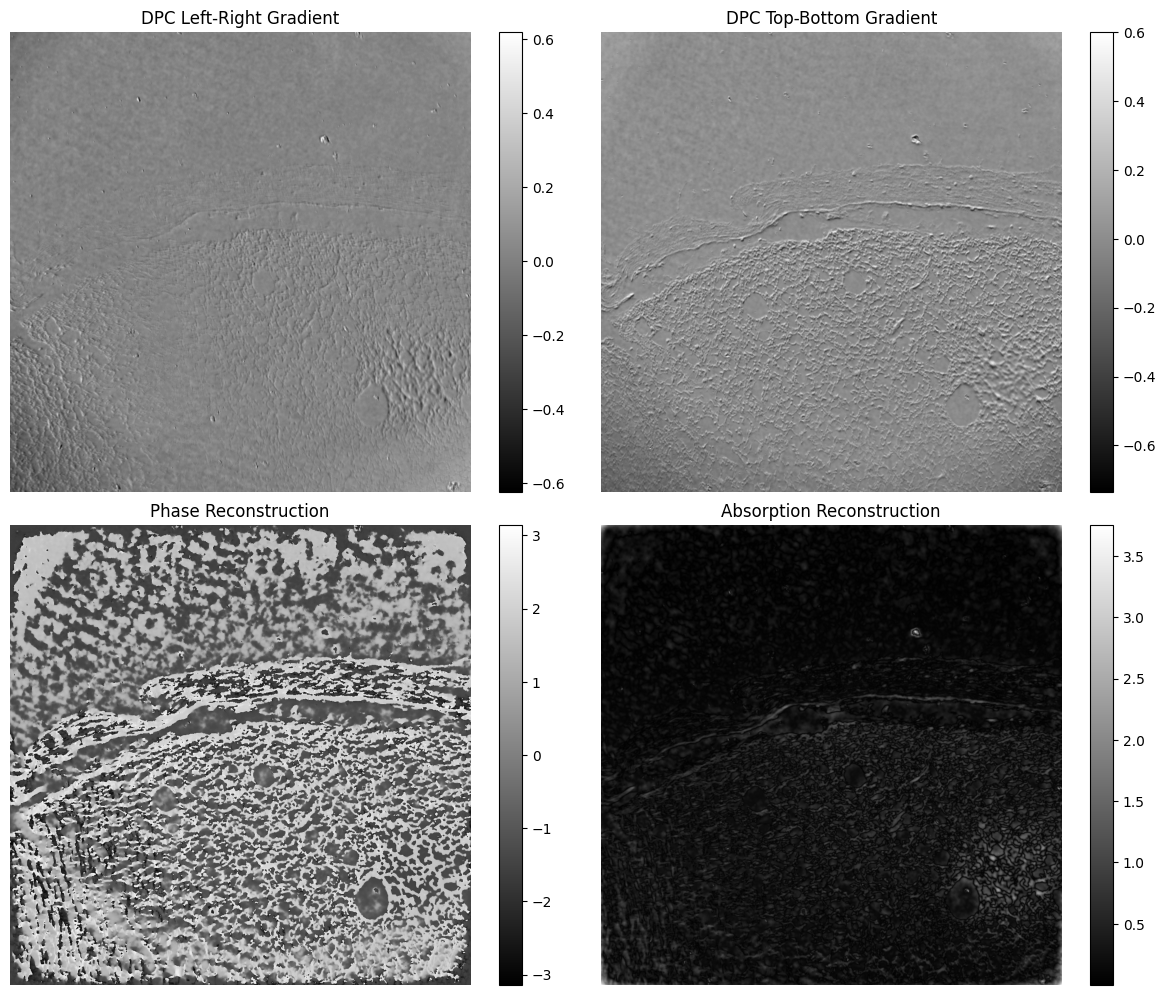

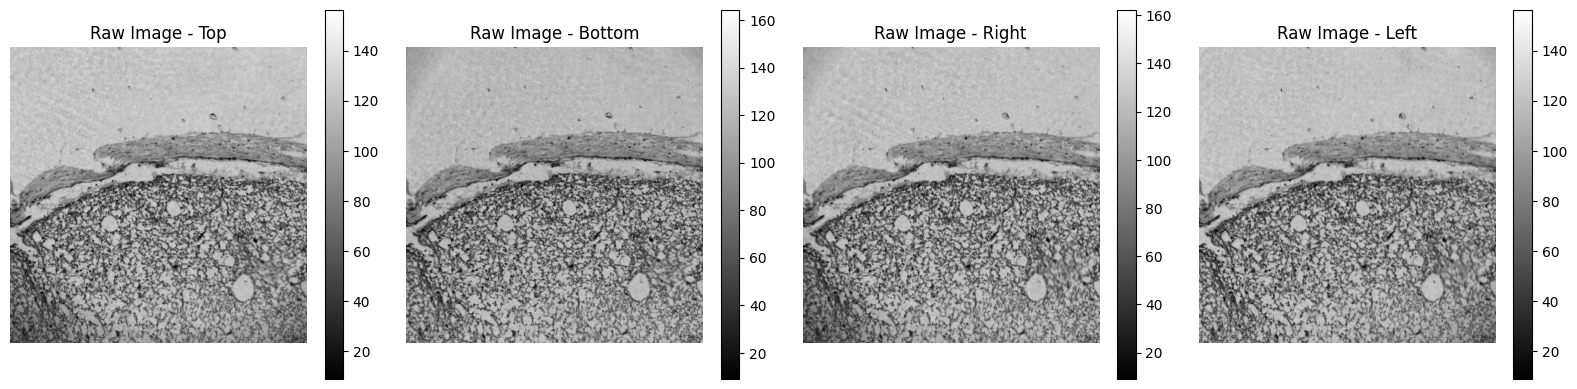

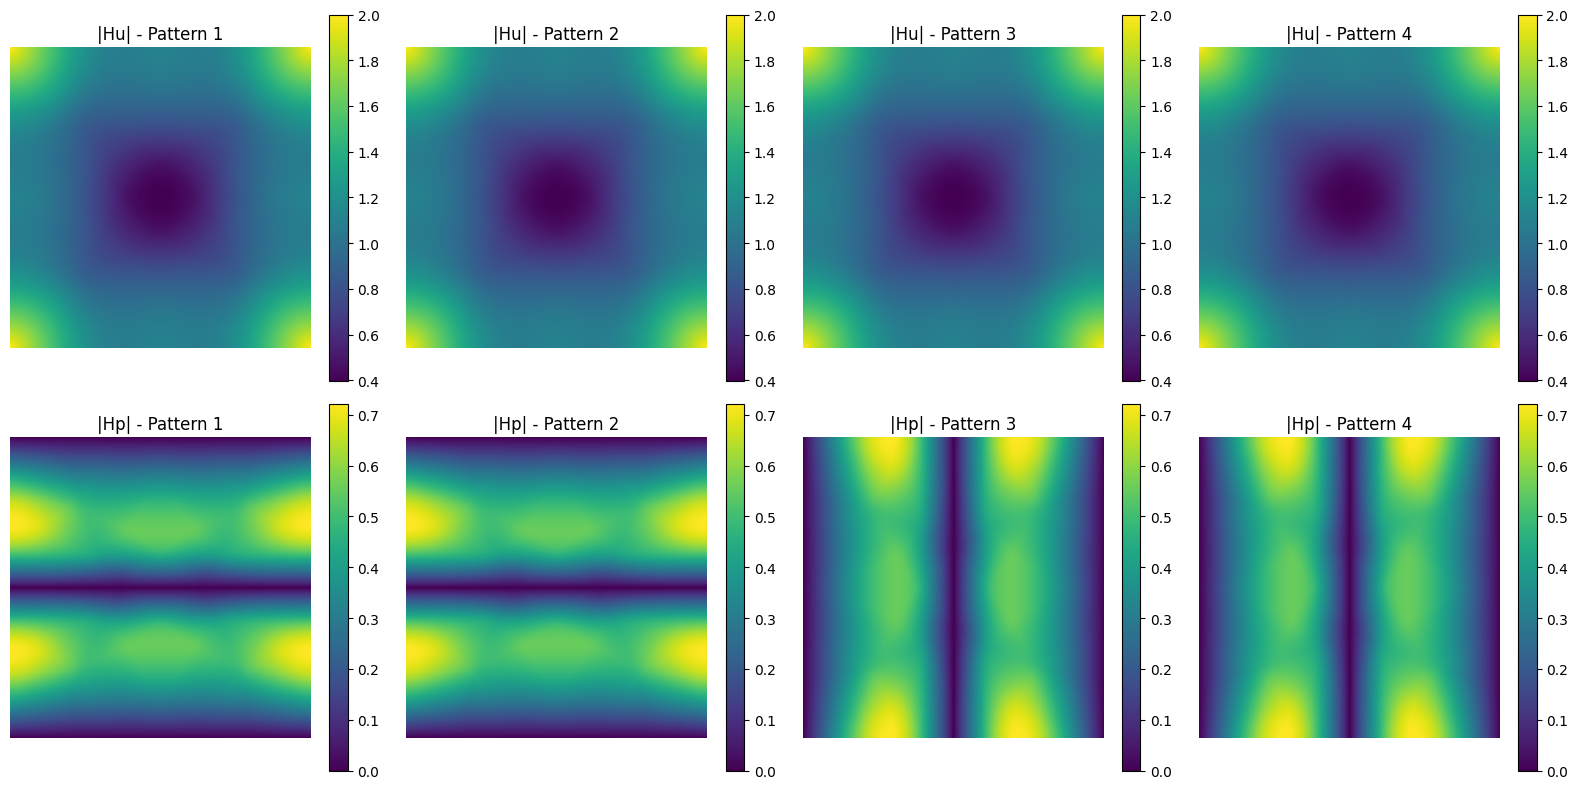


=== DPC Processing Complete ===


In [30]:

# crop images 
crop_size = 1024
center_y, center_x = frame_shape[0] // 2, frame_shape[1] // 2
start_y = max(center_y - crop_size // 2, 0)
end_y = min(center_y + crop_size // 2, frame_shape[0])
start_x = max(center_x - crop_size // 2, 0)
end_x = min(center_x + crop_size // 2, frame_shape[1])
stack = stack[:, start_y:end_y, start_x:end_x]
frame_shape = (end_y - start_y, end_x - start_x)


# adjust configuration
config.pixelsize=0.53
config.na=0.2
config.nai=0.
config.n=1.0
# Regularization
config.reg_u=2e-1
config.reg_p=5e-3
    
    
# Initialize processor
print("\nInitializing DPC processor...")
processor = DPCProcessor(shape=frame_shape, config=config)

if stack is None:
    print("Error: Failed to capture DPC stack")

print(f"Captured stack with shape: {stack.shape}")

# Process stack
print("\nProcessing DPC stack...")
t_start = time.time()
result = processor.process_stack(stack)
t_end = time.time()

if result is None:
    print("Error: DPC processing failed")

dpc_lr, dpc_tb, qdpc_result = result
print(f"Processing completed in {t_end - t_start:.3f} seconds")

# Clean up - disconnect socket if connected
try:
    if hasattr(client, 'socketClient') and client.socketClient is not None:
        if hasattr(client.socketClient, 'sio') and client.socketClient.sio.connected:
            client.socketClient.sio.disconnect()
            print("Socket.IO disconnected")
except Exception as e:
    # Ignore socket disconnect errors
    pass

# Visualize results
print("\nVisualizing results...")
visualize_dpc_results(dpc_lr, dpc_tb, qdpc_result)
visualize_raw_images(stack)
visuaalize_transfer_function(processor.dpc_solver)
print("\n=== DPC Processing Complete ===")

